# CLEF CheckThat! 2026 Task 2 -- Qwen3-Embedding Retrieval Ranking + Dual Veracity Classifiers
## Kaggle 2xT4 -- `Qwen/Qwen3-Embedding-4B` -- Recall@5 + MLP/XGBoost Veracity Classifiers

**Pipeline:**
1. Load train/val/test JSON.
2. Embed `claim` + each `Reasoning_traces` entry with Qwen3-Embedding-4B (Qwen3 backbone, last-token pool, left padding).
3. Rank traces per claim by cosine(claim, trace); sort `Verdict_list` by same order; compute Recall@5 vs golden `label`/`Label`.

## 1. Setup

In [1]:
!pip install -q "transformers>=4.44.0" accelerate sentencepiece xgboost tqdm scikit-learn
print("done")


done


In [2]:
import json, os, gc, time, random, copy, csv, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, accuracy_score,
)

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel

import warnings
warnings.filterwarnings("ignore")

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {p.name}  {p.total_memory/1e9:.1f} GB")


PyTorch : 2.10.0+cu128
CUDA    : True
  GPU 0: Tesla T4  15.6 GB
  GPU 1: Tesla T4  15.6 GB


## 2. Paths & Config

In [3]:
# ============================================================
# PATHS
# ============================================================
TRAIN_JSON = r"/kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/train.json"
VAL_JSON   = r"/kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/validation.json"
TEST_JSON  = r"/kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/test.json"

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# If ablation-study.ipynb already generated Qwen3-Embedding-4B embeddings and
# saved them as a Kaggle dataset/output, point these at that .npz instead of
# OUTPUT_DIR -- generate_embeddings_for_split() will detect the file exists
# and load it directly, skipping embedding generation entirely.
PREGEN_EMB_DIR = "/kaggle/input/datasets/d202511054/qwen3-embeddings"  # <-- set to real path
TRAIN_EMB_PATH = f"{PREGEN_EMB_DIR}/train_qwen3_embeddings.npz"
VAL_EMB_PATH   = f"{PREGEN_EMB_DIR}/val_qwen3_embeddings.npz"
TEST_EMB_PATH  = f"{PREGEN_EMB_DIR}/test_qwen3_embeddings.npz"

# ============================================================
# EMBEDDING MODEL CONFIG
# Qwen3-Embedding-4B: Qwen3 decoder-only backbone,
# last-token pooling, left padding, max 8k context. (verified from model card:
# https://huggingface.co/Qwen/Qwen3-Embedding-4B)
# ============================================================
EMBEDDING_MODEL_ID   = "Qwen/Qwen3-Embedding-4B"
EMBEDDING_BATCH_SIZE = 4          # conservative for 16GB T4
MAX_SEQ_LENGTH       = 8192
NORMALIZE_EMBEDDINGS = True

# ============================================================
# DATA FIELD NAMES
# ============================================================
CLAIM_FIELD         = "claim"
TRACE_TEXT_FIELD    = "Reasoning_traces"   # capital R, per your data
VERDICT_LIST_FIELD  = "Verdict_list"
EVIDENCE_FIELD       = "evidences"

# ============================================================
# LABELS
# ============================================================
label_map         = {"False": 0, "True": 1, "Conflicting": 2}
reverse_label_map = {0: "False", 1: "True", 2: "Conflicting"}

# ============================================================
# TRAINING CONFIG (preserved from your ablation/xgboost notebooks)
# ============================================================
BATCH_SIZE           = 16
MAX_ITERS             = 100
LEARNING_RATE         = 1e-3
EARLY_STOP_PATIENCE   = 20
WEIGHT_DECAY          = 1e-5
GRAD_CLIP_NORM        = 1.0
TRACE_MAX             = 20
SCALAR_DIM            = 7
EXPANDED_SCALAR_DIM   = 1024
ATTN_HIDDEN           = 256
HIDDEN_DIMS           = [512, 256, 128]
OUTPUT_DIM            = 3
RECALL_AT_K           = 5
RANDOM_SEED           = 42
DEVICE                = "cuda" if torch.cuda.is_available() else "cpu"

print("Config set. EMB_DIM will be auto-detected from the loaded model.")


Config set. EMB_DIM will be auto-detected from the loaded model.


In [4]:
def set_seed(seed: int = RANDOM_SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed()
print(f"Seed {RANDOM_SEED} set.")


Seed 42 set.


## 3. Load JSON Data

In [5]:
def load_json(path: str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def numpy_to_python(obj):
    if isinstance(obj, np.integer):    return int(obj)
    if isinstance(obj, np.floating):   return float(obj)
    if isinstance(obj, np.ndarray):    return obj.tolist()
    if isinstance(obj, dict):          return {k: numpy_to_python(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [numpy_to_python(i) for i in obj]
    return obj

print("Loading JSON datasets...")
_train_data = load_json(TRAIN_JSON)
_val_data   = load_json(VAL_JSON)
_test_data  = load_json(TEST_JSON)

print(f"Train items : {len(_train_data)}")
print(f"Val items   : {len(_val_data)}")
print(f"Test items  : {len(_test_data)}")

if _train_data: print(f"\nTrain keys : {list(_train_data[0].keys())}")
if _val_data:   print(f"Val keys   : {list(_val_data[0].keys())}")
if _test_data:  print(f"Test keys  : {list(_test_data[0].keys())}")

# sanity check trace/verdict list lengths (should be 15 or 20)
for name, data in [("train", _train_data), ("val", _val_data), ("test", _test_data)]:
    lens = Counter(len(item.get(TRACE_TEXT_FIELD, [])) for item in data)
    print(f"[{name}] trace-count distribution: {dict(lens)}")


Loading JSON datasets...
Train items : 6400
Val items   : 1600
Test items  : 2558

Train keys : ['Reasoning_traces', 'Verdict_list', 'claim', 'evidences', 'label', 'verdict']
Val keys   : ['Reasoning_traces', 'Verdict_list', 'claim', 'evidences', 'label', 'verdict']
Test keys  : ['Reasoning_traces', 'Verdict_list', 'claim', 'evidences', 'Label', 'verdict', 'query_id']
[train] trace-count distribution: {20: 6204, 15: 196}
[val] trace-count distribution: {15: 1600}
[test] trace-count distribution: {20: 2558}


In [6]:
# ============================================================
# ID MAPPINGS
# train/val use "label" (lowercase), test uses "Label" (capital L)
#
# IMPORTANT: ids must line up with the keys already present in the
# pregenerated .npz caches (id_0, id_1, ...), NOT a fresh 0-based
# enumerate(). Different source notebooks can start numbering at
# different offsets (e.g. ablation-study.ipynb's train cache starts at
# id_1, not id_0), so we derive the id order from the .npz itself.
# ============================================================
def create_id_to_item(data, label_key, cache_path=None):
    mapping = {}
    if cache_path is not None and os.path.exists(cache_path):
        with np.load(cache_path, allow_pickle=False) as npz:
            npz_ids = sorted(
                (int(k.split("_", 1)[1]) for k in npz.files if k.startswith("id_")),
            )
        if len(npz_ids) != len(data):
            raise ValueError(
                f"{cache_path}: npz has {len(npz_ids)} ids but JSON has {len(data)} items "
                "-- can't safely align by position."
            )
        for pos, item in enumerate(data):
            if label_key not in item:
                raise KeyError(f"item {pos} missing label key '{label_key}'")
            mapping[npz_ids[pos]] = item
        return mapping

    # fallback: no cache yet (embeddings about to be generated fresh) -> plain 0-based ids
    for idx, item in enumerate(data):
        if label_key not in item:
            raise KeyError(f"item {idx} missing label key '{label_key}'")
        mapping[idx] = item
    return mapping

train_id_to_item = create_id_to_item(_train_data, "label", TRAIN_EMB_PATH)
val_id_to_item   = create_id_to_item(_val_data,   "label", VAL_EMB_PATH)
test_id_to_item  = create_id_to_item(_test_data,  "Label", TEST_EMB_PATH)

print(f"Train ID->item : {len(train_id_to_item)}  (ids {min(train_id_to_item):d}..{max(train_id_to_item):d})")
print(f"Val ID->item   : {len(val_id_to_item)}  (ids {min(val_id_to_item):d}..{max(val_id_to_item):d})")
print(f"Test ID->item  : {len(test_id_to_item)}  (ids {min(test_id_to_item):d}..{max(test_id_to_item):d})")


Train ID->item : 6400  (ids 1..6400)
Val ID->item   : 1600  (ids 0..1599)
Test ID->item  : 2558  (ids 0..2604)


## 4. Qwen3-Embedding-4B -- Load Model

In [7]:
print(f"Loading tokenizer : {EMBEDDING_MODEL_ID}")
_emb_tokenizer = AutoTokenizer.from_pretrained(
    EMBEDDING_MODEL_ID, padding_side="left", trust_remote_code=True
)

print(f"Loading model      : {EMBEDDING_MODEL_ID}  (bfloat16, device_map=auto)")
_emb_model = AutoModel.from_pretrained(
    EMBEDDING_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",
)
_emb_model.eval()

EMB_DIM = _emb_model.config.hidden_size   # auto-detected, per your instruction
COMBINED_DIM = EMB_DIM * 3 + SCALAR_DIM

print(f"EMB_DIM      : {EMB_DIM}  (auto-detected from model config)")
print(f"COMBINED_DIM : {COMBINED_DIM}")


Loading tokenizer : Qwen/Qwen3-Embedding-4B


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading model      : Qwen/Qwen3-Embedding-4B  (bfloat16, device_map=auto)


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

EMB_DIM      : 2560  (auto-detected from model config)
COMBINED_DIM : 7687


In [8]:
# ============================================================
# EMBEDDING HELPERS -- last-token pooling (Qwen3-Embedding official method)
# ============================================================
def last_token_pool(last_hidden_states: torch.Tensor,
                     attention_mask: torch.Tensor) -> torch.Tensor:
    left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
    if left_padding:
        return last_hidden_states[:, -1]
    sequence_lengths = attention_mask.sum(dim=1) - 1
    batch_size = last_hidden_states.shape[0]
    return last_hidden_states[
        torch.arange(batch_size, device=last_hidden_states.device),
        sequence_lengths,
    ]

def _get_trace_text(trace) -> str:
    if isinstance(trace, str):
        return trace
    if isinstance(trace, dict):
        for key in ("text", "content", "response", "reasoning", "trace", "passage"):
            if key in trace:
                return str(trace[key])
        return str(trace)
    return str(trace)

def get_item_texts(item: dict):
    claim_text = item.get(CLAIM_FIELD, "").strip()
    traces_raw = item.get(TRACE_TEXT_FIELD, [])
    trace_texts = [_get_trace_text(t) for t in traces_raw]
    return claim_text, trace_texts

@torch.no_grad()
def encode_texts(texts: list,
                  batch_size: int = EMBEDDING_BATCH_SIZE,
                  max_length: int = MAX_SEQ_LENGTH,
                  normalize: bool = NORMALIZE_EMBEDDINGS) -> np.ndarray:
    all_embeddings = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = _emb_tokenizer(
            batch, padding=True, truncation=True,
            max_length=max_length, return_tensors="pt",
        )
        first_device = next(_emb_model.parameters()).device
        encoded = {k: v.to(first_device) for k, v in encoded.items()}
        outputs = _emb_model(**encoded)
        embeddings = last_token_pool(outputs.last_hidden_state, encoded["attention_mask"])
        if normalize:
            embeddings = F.normalize(embeddings.float(), p=2, dim=-1)
        else:
            embeddings = embeddings.float()
        all_embeddings.append(embeddings.cpu().numpy())
    return np.concatenate(all_embeddings, axis=0)

print("Embedding helpers ready.")


Embedding helpers ready.


## 5. Generate & Cache Embeddings

In [9]:
def generate_embeddings_for_split(id_to_item, id_order, split_name, cache_path):
    """Row 0 = claim embedding, rows 1+ = trace embeddings."""
    if os.path.exists(cache_path):
        print(f"[{split_name}] Cache found -> loading {cache_path}")
        return dict(np.load(cache_path, allow_pickle=False))

    print(f"\n[{split_name}] Generating embeddings for {len(id_order)} items ...")
    emb_dict = {}
    for id_ in tqdm(id_order, desc=f"[{split_name}]"):
        item = id_to_item[id_]
        claim_text, trace_texts = get_item_texts(item)
        if not claim_text:  claim_text = "[EMPTY CLAIM]"
        if not trace_texts: trace_texts = ["[NO TRACE]"]

        claim_emb  = encode_texts([claim_text])
        trace_embs = encode_texts(trace_texts)

        stacked = np.vstack([claim_emb, trace_embs]).astype(np.float32)
        emb_dict[f"id_{id_}"] = stacked

    np.savez_compressed(cache_path, **emb_dict)
    print(f"[{split_name}] Saved -> {cache_path}")
    return dict(np.load(cache_path, allow_pickle=False))


_train_ids_order = sorted(train_id_to_item.keys())
train_emb_data = generate_embeddings_for_split(train_id_to_item, _train_ids_order, "TRAIN", TRAIN_EMB_PATH)

_val_ids_order = sorted(val_id_to_item.keys())
val_emb_data = generate_embeddings_for_split(val_id_to_item, _val_ids_order, "VAL", VAL_EMB_PATH)

_test_ids_order = sorted(test_id_to_item.keys())
test_emb_data = generate_embeddings_for_split(test_id_to_item, _test_ids_order, "TEST", TEST_EMB_PATH)

print("\nEmbedding generation complete.")


[TRAIN] Cache found -> loading /kaggle/input/datasets/d202511054/qwen3-embeddings/train_qwen3_embeddings.npz
[VAL] Cache found -> loading /kaggle/input/datasets/d202511054/qwen3-embeddings/val_qwen3_embeddings.npz
[TEST] Cache found -> loading /kaggle/input/datasets/d202511054/qwen3-embeddings/test_qwen3_embeddings.npz

Embedding generation complete.


## 6. Recall@5 via Cosine Similarity Ranking

For each item: cosine(claim_emb, trace_emb) for every trace -> rank traces high->low ->
reorder `Verdict_list` by the same order -> take top-5 verdicts -> check if golden `label`
appears among them (majority-vote hit) -> Recall@5.

Definition used: **hit@5 = 1** if the golden label is present at least once among the
top-5 ranked verdicts, **0** otherwise. Recall@5 = mean(hit@5) over all items in a split.


In [23]:
def cosine_rank_recall_at_k(id_to_item, emb_data, label_key, k=RECALL_AT_K):
    """
    Computes IR-style Recall@k:
        Recall@k = (# relevant traces in Top-k) / (# relevant traces in all reasoning traces)

    A reasoning trace is considered relevant if its verdict matches the gold label.

    Returns:
        recall_at_k (float): Mean Recall@k over all samples.
        per_item_records (list): Per-sample details.
    """
    hits = []
    records = []
    skipped_missing = 0

    for id_, item in id_to_item.items():

        # Find the corresponding embedding array
        key_candidates = [f"id_{id_}", str(id_)]
        arr = None
        for key in key_candidates:
            if key in emb_data:
                arr = emb_data[key]
                break

        if arr is None:
            skipped_missing += 1
            continue

        claim_emb = arr[0]
        trace_embs = arr[1:]

        verdict_list = item.get(VERDICT_LIST_FIELD, [])
        n = min(trace_embs.shape[0], len(verdict_list))

        if n == 0:
            continue

        trace_embs = trace_embs[:n]
        verdicts = verdict_list[:n]

        # Cosine similarity
        sims = trace_embs @ claim_emb / (
            np.linalg.norm(trace_embs, axis=1) *
            np.linalg.norm(claim_emb) + 1e-9
        )

        # Rank traces by similarity
        order = np.argsort(-sims)

        ranked_verdicts = [verdicts[i] for i in order]
        ranked_sims = [float(sims[i]) for i in order]

        gold = item.get(label_key)
        top_k_verdicts = ranked_verdicts[:k]

        # IR-style Recall@k
        total_relevant = sum(v == gold for v in verdicts)
        retrieved_relevant = sum(v == gold for v in top_k_verdicts)

        recall_score = (
            retrieved_relevant / total_relevant
            if total_relevant > 0
            else 0.0
        )

        hits.append(recall_score)

        records.append({
            "id": id_,
            "gold": gold,
            "total_relevant": total_relevant,
            "retrieved_relevant": retrieved_relevant,
            "top_k_verdicts": top_k_verdicts,
            "top_k_sims": ranked_sims[:k],
            "recall_at_k": recall_score,
        })

    if skipped_missing:
        print(
            f"[cosine_rank_recall_at_k] WARNING: "
            f"{skipped_missing} item(s) had no matching key in emb_data and were skipped."
        )

    recall = float(np.mean(hits)) if hits else 0.0

    return recall, records


# Compute Recall@5
train_recall5, train_recall_records = cosine_rank_recall_at_k(
    train_id_to_item, train_emb_data, "label"
)

val_recall5, val_recall_records = cosine_rank_recall_at_k(
    val_id_to_item, val_emb_data, "label"
)

test_recall5, test_recall_records = cosine_rank_recall_at_k(
    test_id_to_item, test_emb_data, "Label"
)

print(f"Recall@{RECALL_AT_K} TRAIN : {train_recall5:.4f}")
print(f"Recall@{RECALL_AT_K} VAL   : {val_recall5:.4f}")
print(f"Recall@{RECALL_AT_K} TEST  : {test_recall5:.4f}")

Recall@5 TRAIN : 0.4734
Recall@5 VAL   : 0.4906
Recall@5 TEST  : 0.7611


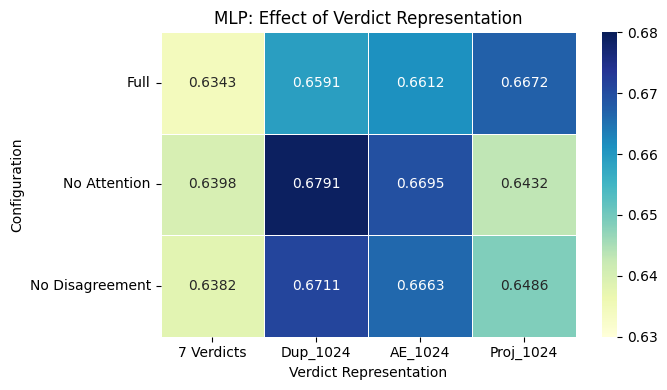

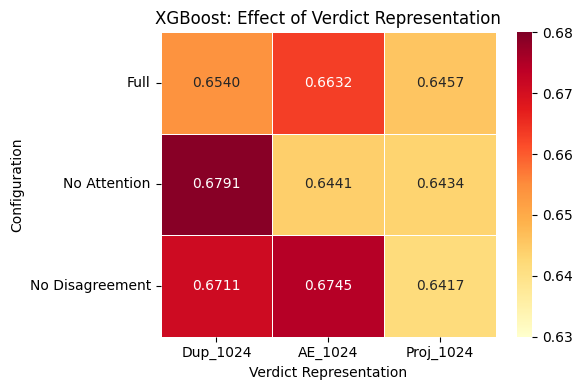

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------
# Table 1: MLP
# -------------------------------

mlp = pd.DataFrame(
    [
        [0.6343, 0.6591, 0.6612, 0.6672],
        [0.6398, 0.6791, 0.6695, 0.6432],
        [0.6382, 0.6711, 0.6663, 0.6486],
    ],
    index=[
        "Full",
        "No Attention",
        "No Disagreement"
    ],
    columns=[
        "7 Verdicts",
        "Dup_1024",
        "AE_1024",
        "Proj_1024"
    ]
)

plt.figure(figsize=(7,4))

sns.heatmap(
    mlp,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    vmin=0.63,
    vmax=0.68,
    linewidths=0.5
)

plt.title("MLP: Effect of Verdict Representation")
plt.xlabel("Verdict Representation")
plt.ylabel("Configuration")
plt.tight_layout()
plt.show()


# -------------------------------
# Table 2: XGBoost
# -------------------------------

xgb = pd.DataFrame(
    [
        [0.6540, 0.6632, 0.6457],
        [0.6791, 0.6441, 0.6434],
        [0.6711, 0.6745, 0.6417],
    ],
    index=[
        "Full",
        "No Attention",
        "No Disagreement"
    ],
    columns=[
        "Dup_1024",
        "AE_1024",
        "Proj_1024"
    ]
)

plt.figure(figsize=(6,4))

sns.heatmap(
    xgb,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    vmin=0.63,
    vmax=0.68,
    linewidths=0.5
)

plt.title("XGBoost: Effect of Verdict Representation")
plt.xlabel("Verdict Representation")
plt.ylabel("Configuration")
plt.tight_layout()
plt.show()